# Comprehensive Vulnerability Detection Analysis

**Purpose**: Unified analysis of ALL vulnerability detection experiments across all phases.

**Datasets**: 18 experiments across mars/, mars_rerun/, runpod/, and runpod_rerun/

**Research Questions**:
- **RQ1**: How do model size and reasoning capabilities affect vulnerability detection accuracy?
- **RQ2**: What is the trade-off between prompting strategy and performance/energy?
- **RQ3**: How does hardware (RTX A5000 vs H100) impact performance and energy efficiency?

**Date**: November 8, 2025

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_FILE = PROJECT_ROOT / 'results' / 'analysis' / 'vuln_detection_master_dataset.csv'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Project Root: {PROJECT_ROOT}")
print(f"📊 Data File: {DATA_FILE}")
print(f"💾 Output Directory: {OUTPUT_DIR}")

📂 Project Root: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green
📊 Data File: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis/vuln_detection_master_dataset.csv
💾 Output Directory: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis


In [2]:
# Load data
df = pd.read_csv(DATA_FILE)

print(f"\n📊 Dataset loaded: {len(df)} experiments")
print(f"\nColumns: {list(df.columns)}")

# Display first few rows
df.head()


📊 Dataset loaded: 16 experiments

Columns: ['experiment_id', 'phase', 'hardware', 'model_size', 'model_type', 'prompting', 'prompt_version', 'full_model_name', 'timestamp', 'result_directory', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'True_Positives', 'True_Negatives', 'False_Positives', 'False_Negatives', 'Total_Samples', 'Correct_Predictions', 'total_emissions_kg', 'num_sessions', 'start_time', 'end_time', 'samples_processed', 'duration_seconds', 'emissions_kg_codecarbon', 'energy_consumed_kwh', 'cpu_energy_kwh', 'gpu_energy_kwh', 'ram_energy_kwh', 'gpu_model', 'cpu_model', 'num_codecarbon_sessions']


,experiment_id,phase,hardware,model_size,model_type,prompting,prompt_version,full_model_name,timestamp,result_directory,...,samples_processed,duration_seconds,emissions_kg_codecarbon,energy_consumed_kwh,cpu_energy_kwh,gpu_energy_kwh,ram_energy_kwh,gpu_model,cpu_model,num_codecarbon_sessions
0,4B_Instruct_Few-shot_Phase 1 (Mars Initial),Phase 1 (Mars Initial),Mars (RTX A5000),4B,Instruct,Few-shot,LLM-generated,Qwen-Qwen3-4B-Instruct-2507,20251011-110256,results/mars,...,386,4530.457325,0.113401,0.666897,0.141576,0.287759,0.237562,1 x NVIDIA RTX A5000,AMD EPYC 7643 48-Core Processor,3
1,4B_Instruct_Zero-shot_Phase 1 (Mars Initial),Phase 1 (Mars Initial),Mars (RTX A5000),4B,Instruct,Zero-shot,Zero-shot (no examples),Qwen-Qwen3-4B-Instruct-2507,20251011-083716,results/mars,...,386,6182.034128,0.154753,0.910080,0.193187,0.392819,0.324074,1 x NVIDIA RTX A5000,AMD EPYC 7643 48-Core Processor,1
2,4B_Thinking_Few-shot_Phase 1 (Mars Initial),Phase 1 (Mars Initial),Mars (RTX A5000),4B,Thinking,Few-shot,LLM-generated,Qwen-Qwen3-4B-Thinking-2507,20251011-110932,results/mars,...,386,17845.246098,0.446900,2.628159,0.557661,1.134846,0.935653,1 x NVIDIA RTX A5000,AMD EPYC 7643 48-Core Processor,4
3,4B_Thinking_Zero-shot_Phase 1 (Mars Initial),Phase 1 (Mars Initial),Mars (RTX A5000),4B,Thinking,Zero-shot,Zero-shot (no examples),Qwen-Qwen3-4B-Thinking-2507,20251011-110220,results/mars,...,386,29197.865386,0.731428,4.301432,0.912428,1.857982,1.531022,1 x NVIDIA RTX A5000,AMD EPYC 7643 48-Core Processor,6
4,4B_Instruct_Few-shot_Phase 1b (Mars Rerun),Phase 1b (Mars Rerun),Mars (RTX A5000),4B,Instruct,Few-shot,CWE-based,Qwen-Qwen3-4B-Instruct-2507,20251101-200224,results/mars_rerun,...,386,8334.212454,0.125384,0.737364,0.051083,0.529661,0.156619,1 x NVIDIA RTX A5000,AMD EPYC 7643 48-Core Processor,1


## 2. Data Cleaning & Preprocessing

In [3]:
# Remove failed/incomplete experiments
print("🧹 Cleaning data...")
print(f"Original size: {len(df)} experiments")

# Remove experiments with 0% accuracy or suspiciously low sample counts
df_clean = df[(df['Accuracy'] > 0) & (df['Total_Samples'] > 100)].copy()

print(f"After removing failed experiments: {len(df_clean)} experiments")
print(f"Removed: {len(df) - len(df_clean)} failed/incomplete experiments\n")

# Convert percentages to 0-100 scale for better readability
for col in ['Accuracy', 'Precision', 'Recall', 'F1_Score']:
    df_clean[f'{col}_pct'] = df_clean[col] * 100

# Calculate energy per sample
df_clean['energy_per_sample_kwh'] = df_clean['energy_consumed_kwh'] / df_clean['Total_Samples']
df_clean['emissions_per_sample_kg'] = df_clean['emissions_kg_codecarbon'] / df_clean['Total_Samples']

# Duration in hours
df_clean['duration_hours'] = df_clean['duration_seconds'] / 3600

print("✅ Data cleaning complete!")
df_clean.head()

🧹 Cleaning data...
Original size: 16 experiments
After removing failed experiments: 16 experiments
Removed: 0 failed/incomplete experiments

✅ Data cleaning complete!


,experiment_id,phase,hardware,model_size,model_type,prompting,prompt_version,full_model_name,timestamp,result_directory,...,gpu_model,cpu_model,num_codecarbon_sessions,Accuracy_pct,Precision_pct,Recall_pct,F1_Score_pct,energy_per_sample_kwh,emissions_per_sample_kg,duration_hours
0,4B_Instruct_Few-shot_Phase 1 (Mars Initial),Phase 1 (Mars Initial),Mars (RTX A5000),4B,Instruct,Few-shot,LLM-generated,Qwen-Qwen3-4B-Instruct-2507,20251011-110256,results/mars,...,1 x NVIDIA RTX A5000,AMD EPYC 7643 48-Core Processor,3,51.036269,62.500000,5.181347,9.569378,0.001728,0.000294,1.258460
1,4B_Instruct_Zero-shot_Phase 1 (Mars Initial),Phase 1 (Mars Initial),Mars (RTX A5000),4B,Instruct,Zero-shot,Zero-shot (no examples),Qwen-Qwen3-4B-Instruct-2507,20251011-083716,results/mars,...,1 x NVIDIA RTX A5000,AMD EPYC 7643 48-Core Processor,1,50.259067,50.909091,14.507772,22.580645,0.002358,0.000401,1.717232
2,4B_Thinking_Few-shot_Phase 1 (Mars Initial),Phase 1 (Mars Initial),Mars (RTX A5000),4B,Thinking,Few-shot,LLM-generated,Qwen-Qwen3-4B-Thinking-2507,20251011-110932,results/mars,...,1 x NVIDIA RTX A5000,AMD EPYC 7643 48-Core Processor,4,51.295337,53.846154,18.134715,27.131783,0.006809,0.001158,4.957013
3,4B_Thinking_Zero-shot_Phase 1 (Mars Initial),Phase 1 (Mars Initial),Mars (RTX A5000),4B,Thinking,Zero-shot,Zero-shot (no examples),Qwen-Qwen3-4B-Thinking-2507,20251011-110220,results/mars,...,1 x NVIDIA RTX A5000,AMD EPYC 7643 48-Core Processor,6,53.125000,55.339806,29.842932,38.775510,0.011202,0.001905,8.110518
4,4B_Instruct_Few-shot_Phase 1b (Mars Rerun),Phase 1b (Mars Rerun),Mars (RTX A5000),4B,Instruct,Few-shot,CWE-based,Qwen-Qwen3-4B-Instruct-2507,20251101-200224,results/mars_rerun,...,1 x NVIDIA RTX A5000,AMD EPYC 7643 48-Core Processor,1,54.663212,58.653846,31.606218,41.077441,0.001910,0.000325,2.315059


## 3. Exploratory Data Analysis

In [4]:
# Summary statistics
print("📈 Summary Statistics\n")
print("="*80)

summary_cols = ['Accuracy_pct', 'Precision_pct', 'Recall_pct', 'F1_Score_pct', 
                'energy_consumed_kwh', 'emissions_kg_codecarbon', 'duration_hours']

print(df_clean[summary_cols].describe().round(2))

# Count by categories
print("\n" + "="*80)
print("\n📊 Experiment Breakdown:\n")
print(f"By Phase:\n{df_clean['phase'].value_counts()}\n")
print(f"By Model Size:\n{df_clean['model_size'].value_counts()}\n")
print(f"By Model Type:\n{df_clean['model_type'].value_counts()}\n")
print(f"By Prompting:\n{df_clean['prompting'].value_counts()}\n")
print(f"By Hardware:\n{df_clean['hardware'].value_counts()}\n")
print(f"By Prompt Version:\n{df_clean['prompt_version'].value_counts()}")

📈 Summary Statistics

       Accuracy_pct  Precision_pct  Recall_pct  F1_Score_pct  \
count         16.00          16.00       16.00         16.00   
mean          52.58          54.79       39.25         42.34   
std            1.80           3.96       19.86         14.43   
min           50.26          50.21        5.18          9.57   
25%           51.23          51.93       25.52         35.77   
50%           52.59          54.11       38.72         44.85   
75%           53.38          57.22       53.63         54.54   
max           56.22          62.50       67.88         58.88   

       energy_consumed_kwh  emissions_kg_codecarbon  duration_hours  
count                16.00                    16.00           16.00  
mean                  1.58                     0.27            2.95  
std                   1.28                     0.22            2.63  
min                   0.28                     0.05            0.66  
25%                   0.72                     0.12

## 4. RQ1: Model Size & Reasoning Impact Analysis

### 4.1 Performance by Model Size (4B vs 30B)

📊 Performance by Model Size:

            Accuracy_pct  Precision_pct  Recall_pct  F1_Score_pct
model_size                                                       
30B                53.35          54.57       48.92         50.44
4B                 52.13          54.92       33.45         37.48


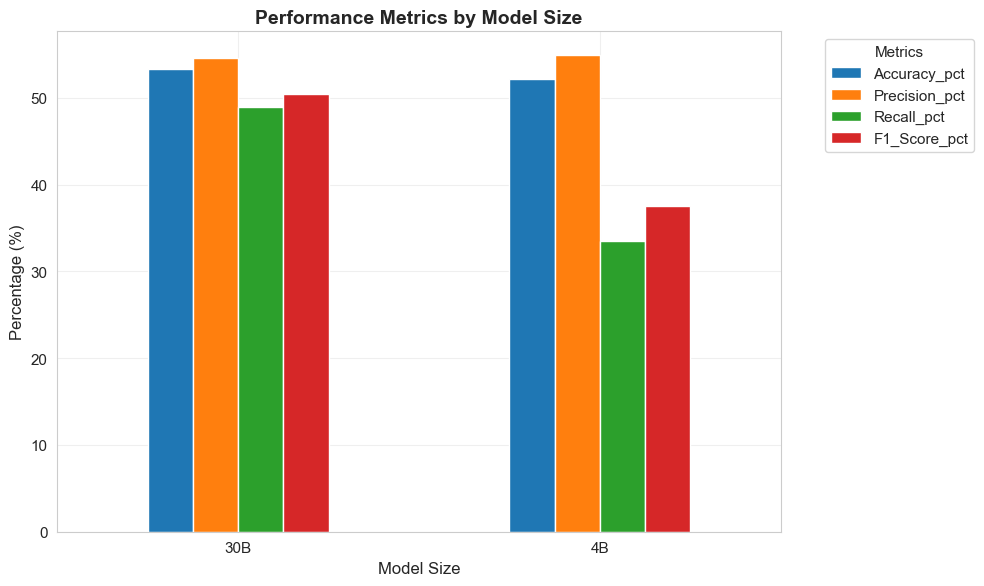


📊 T-test (4B vs 30B Accuracy): t=-1.352, p=0.198
   ⚠️  No statistically significant difference


In [5]:
# Group by model size
model_size_perf = df_clean.groupby('model_size')[['Accuracy_pct', 'Precision_pct', 'Recall_pct', 'F1_Score_pct']].mean()

print("📊 Performance by Model Size:\n")
print(model_size_perf.round(2))

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
model_size_perf.plot(kind='bar', ax=ax, rot=0)
ax.set_title('Performance Metrics by Model Size', fontsize=14, fontweight='bold')
ax.set_xlabel('Model Size', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_model_size_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical test
from scipy import stats
accuracy_4b = df_clean[df_clean['model_size'] == '4B']['Accuracy_pct']
accuracy_30b = df_clean[df_clean['model_size'] == '30B']['Accuracy_pct']
t_stat, p_value = stats.ttest_ind(accuracy_4b, accuracy_30b)
print(f"\n📊 T-test (4B vs 30B Accuracy): t={t_stat:.3f}, p={p_value:.3f}")
if p_value < 0.05:
    print("   ✅ Statistically significant difference!")
else:
    print("   ⚠️  No statistically significant difference")

### 4.2 Performance by Model Type (Instruct vs Thinking)

📊 Performance by Model Type:

            Accuracy_pct  Precision_pct  Recall_pct  F1_Score_pct
model_type                                                       
Instruct           53.37          57.36        28.5         35.54
Thinking           51.80          52.22        50.0         49.15


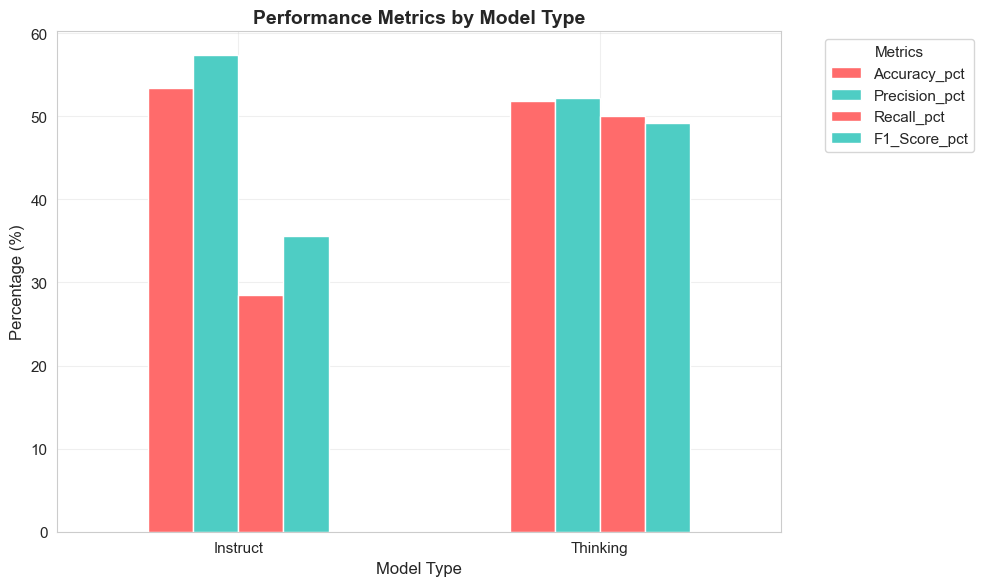


📊 T-test (Instruct vs Thinking Accuracy): t=1.889, p=0.080
   ⚠️  No statistically significant difference


In [6]:
# Group by model type
model_type_perf = df_clean.groupby('model_type')[['Accuracy_pct', 'Precision_pct', 'Recall_pct', 'F1_Score_pct']].mean()

print("📊 Performance by Model Type:\n")
print(model_type_perf.round(2))

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
model_type_perf.plot(kind='bar', ax=ax, rot=0, color=['#FF6B6B', '#4ECDC4'])
ax.set_title('Performance Metrics by Model Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_model_type_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical test
accuracy_instruct = df_clean[df_clean['model_type'] == 'Instruct']['Accuracy_pct']
accuracy_thinking = df_clean[df_clean['model_type'] == 'Thinking']['Accuracy_pct']
t_stat, p_value = stats.ttest_ind(accuracy_instruct, accuracy_thinking)
print(f"\n📊 T-test (Instruct vs Thinking Accuracy): t={t_stat:.3f}, p={p_value:.3f}")
if p_value < 0.05:
    print("   ✅ Statistically significant difference!")
else:
    print("   ⚠️  No statistically significant difference")

### 4.3 Combined: Model Size × Model Type Heatmap

📊 Accuracy Heatmap (Model Size × Model Type):

model_type  Instruct  Thinking
model_size                    
30B            55.18     51.51
4B             52.28     51.97


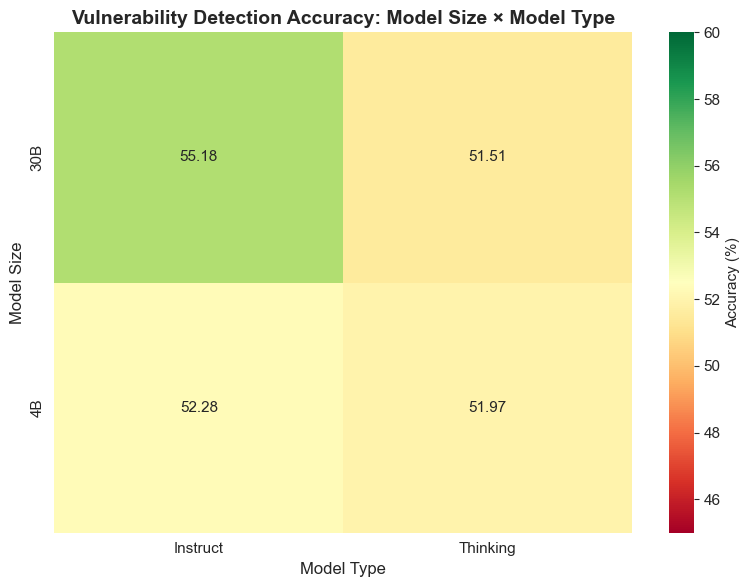

In [7]:
# Pivot table for heatmap
heatmap_data = df_clean.pivot_table(
    values='Accuracy_pct',
    index='model_size',
    columns='model_type',
    aggfunc='mean'
)

print("📊 Accuracy Heatmap (Model Size × Model Type):\n")
print(heatmap_data.round(2))

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', vmin=45, vmax=60, 
            cbar_kws={'label': 'Accuracy (%)'})
plt.title('Vulnerability Detection Accuracy: Model Size × Model Type', fontsize=14, fontweight='bold')
plt.xlabel('Model Type', fontsize=12)
plt.ylabel('Model Size', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_accuracy_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. RQ2: Prompting Strategy Analysis

### 5.1 Zero-shot vs Few-shot Performance

📊 Performance by Prompting Strategy:

           Accuracy_pct  Precision_pct  Recall_pct  F1_Score_pct
prompting                                                       
Few-shot          52.79          55.37       40.75         43.00
Zero-shot         52.25          53.82       36.75         41.25


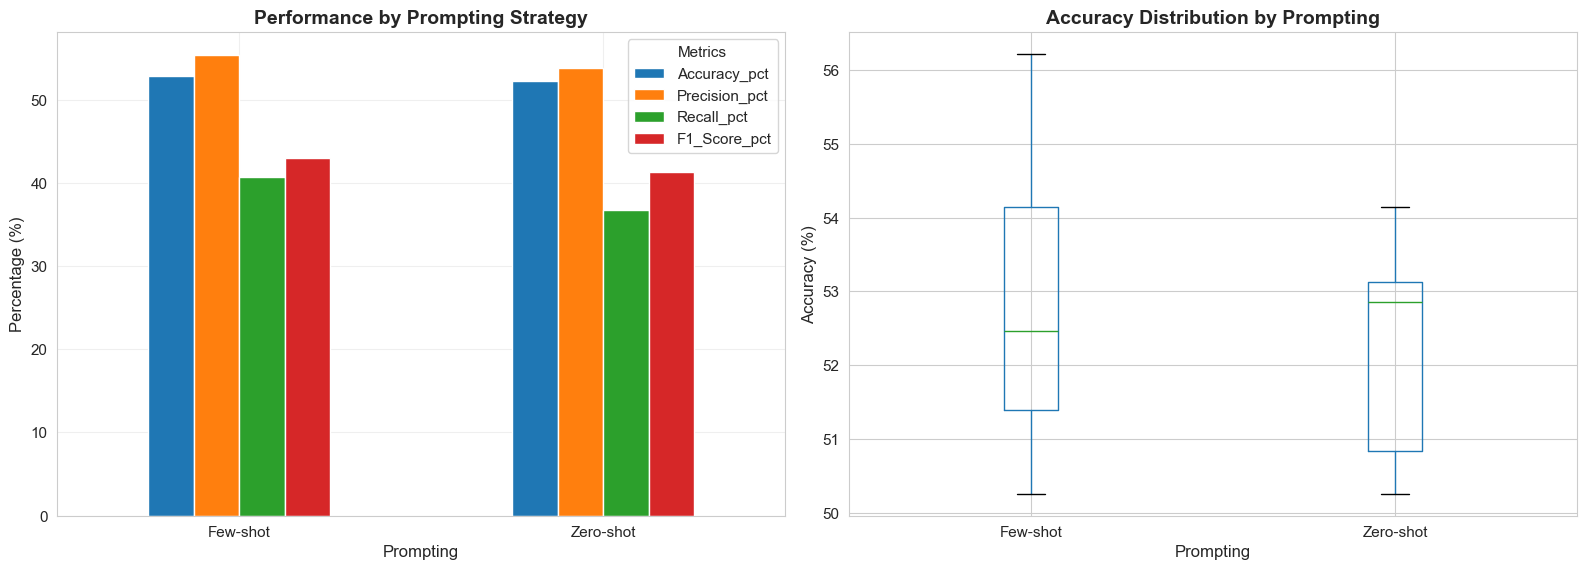

In [8]:
# Group by prompting strategy
prompting_perf = df_clean.groupby('prompting')[['Accuracy_pct', 'Precision_pct', 'Recall_pct', 'F1_Score_pct']].mean()

print("📊 Performance by Prompting Strategy:\n")
print(prompting_perf.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
prompting_perf.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Performance by Prompting Strategy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prompting', fontsize=12)
axes[0].set_ylabel('Percentage (%)', fontsize=12)
axes[0].legend(title='Metrics')
axes[0].grid(True, alpha=0.3)

# Box plot
df_clean.boxplot(column='Accuracy_pct', by='prompting', ax=axes[1])
axes[1].set_title('Accuracy Distribution by Prompting', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Prompting', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
plt.suptitle('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_prompting_performance.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.2 Prompt Version Impact (LLM-generated vs CWE-based)

📊 Performance by Prompt Version:

                         Accuracy_pct  F1_Score_pct
prompt_version                                     
CWE-based                       53.11         51.11
LLM-generated                   52.30         30.83
Zero-shot (no examples)         52.25         41.25


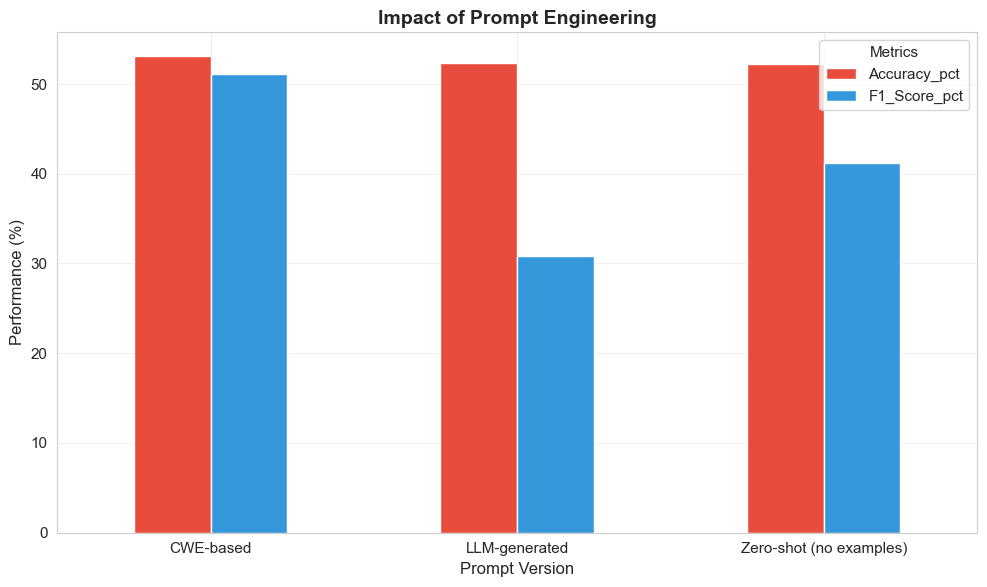

In [9]:
# Compare prompt versions (mars vs mars_rerun)
prompt_comparison = df_clean.groupby('prompt_version')[['Accuracy_pct', 'F1_Score_pct']].mean()

print("📊 Performance by Prompt Version:\n")
print(prompt_comparison.round(2))

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
prompt_comparison.plot(kind='bar', ax=ax, rot=0, color=['#E74C3C', '#3498DB'])
ax.set_title('Impact of Prompt Engineering', fontsize=14, fontweight='bold')
ax.set_xlabel('Prompt Version', fontsize=12)
ax.set_ylabel('Performance (%)', fontsize=12)
ax.legend(title='Metrics')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_prompt_version_impact.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. RQ3: Hardware Comparison Analysis

### 6.1 Mars (RTX A5000) vs RunPod (H100) - 4B Models

📊 4B Models: Hardware Comparison

                  Accuracy_pct  F1_Score_pct  energy_consumed_kwh  \
hardware                                                            
Mars (RTX A5000)         52.16          33.0                 2.05   
RunPod (H100)            52.07          44.2                 2.02   

                  duration_hours  
hardware                          
Mars (RTX A5000)            4.67  
RunPod (H100)               2.05  


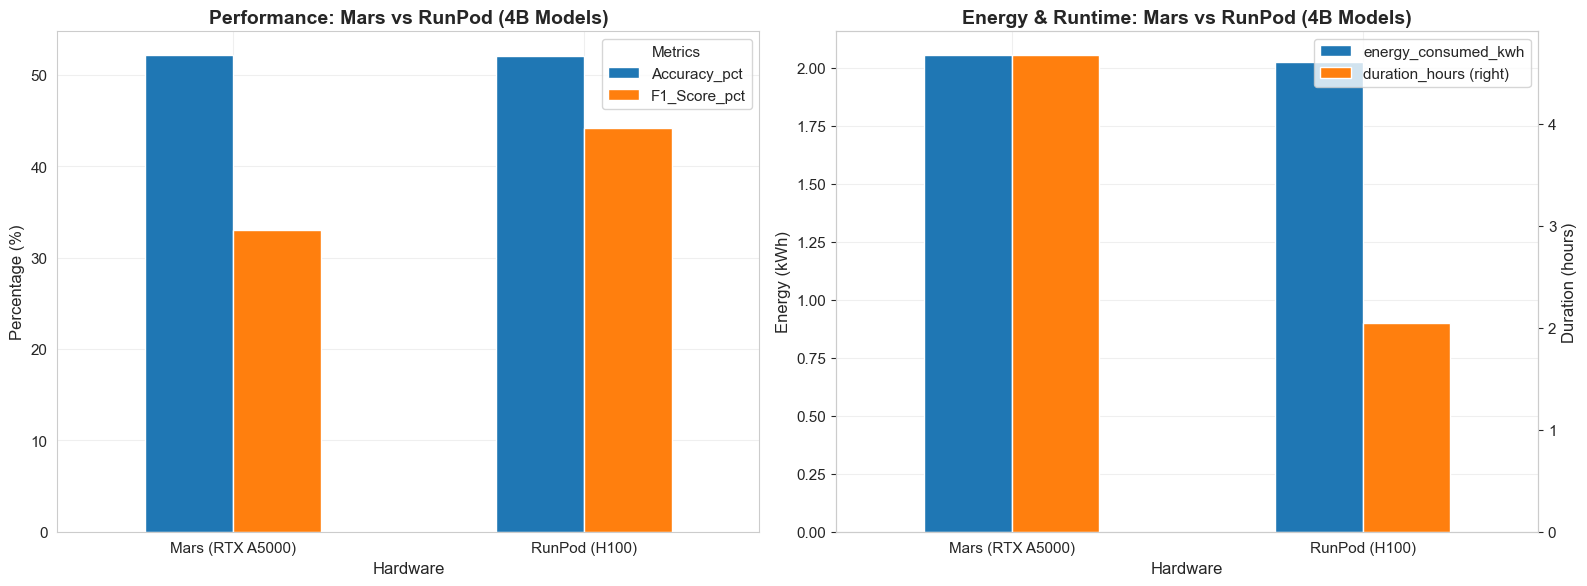

In [10]:
# Filter 4B models only for fair hardware comparison
df_4b = df_clean[df_clean['model_size'] == '4B'].copy()

# Compare performance by hardware
hardware_perf = df_4b.groupby('hardware')[['Accuracy_pct', 'F1_Score_pct', 'energy_consumed_kwh', 'duration_hours']].mean()

print("📊 4B Models: Hardware Comparison\n")
print(hardware_perf.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Performance comparison
hardware_perf[['Accuracy_pct', 'F1_Score_pct']].plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Performance: Mars vs RunPod (4B Models)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hardware', fontsize=12)
axes[0].set_ylabel('Percentage (%)', fontsize=12)
axes[0].legend(title='Metrics')
axes[0].grid(True, alpha=0.3)

# Energy comparison
hardware_perf[['energy_consumed_kwh', 'duration_hours']].plot(kind='bar', ax=axes[1], rot=0, secondary_y=['duration_hours'])
axes[1].set_title('Energy & Runtime: Mars vs RunPod (4B Models)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hardware', fontsize=12)
axes[1].set_ylabel('Energy (kWh)', fontsize=12)
axes[1].right_ax.set_ylabel('Duration (hours)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_hardware_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Energy Efficiency Analysis

### 7.1 Energy Consumption by Configuration

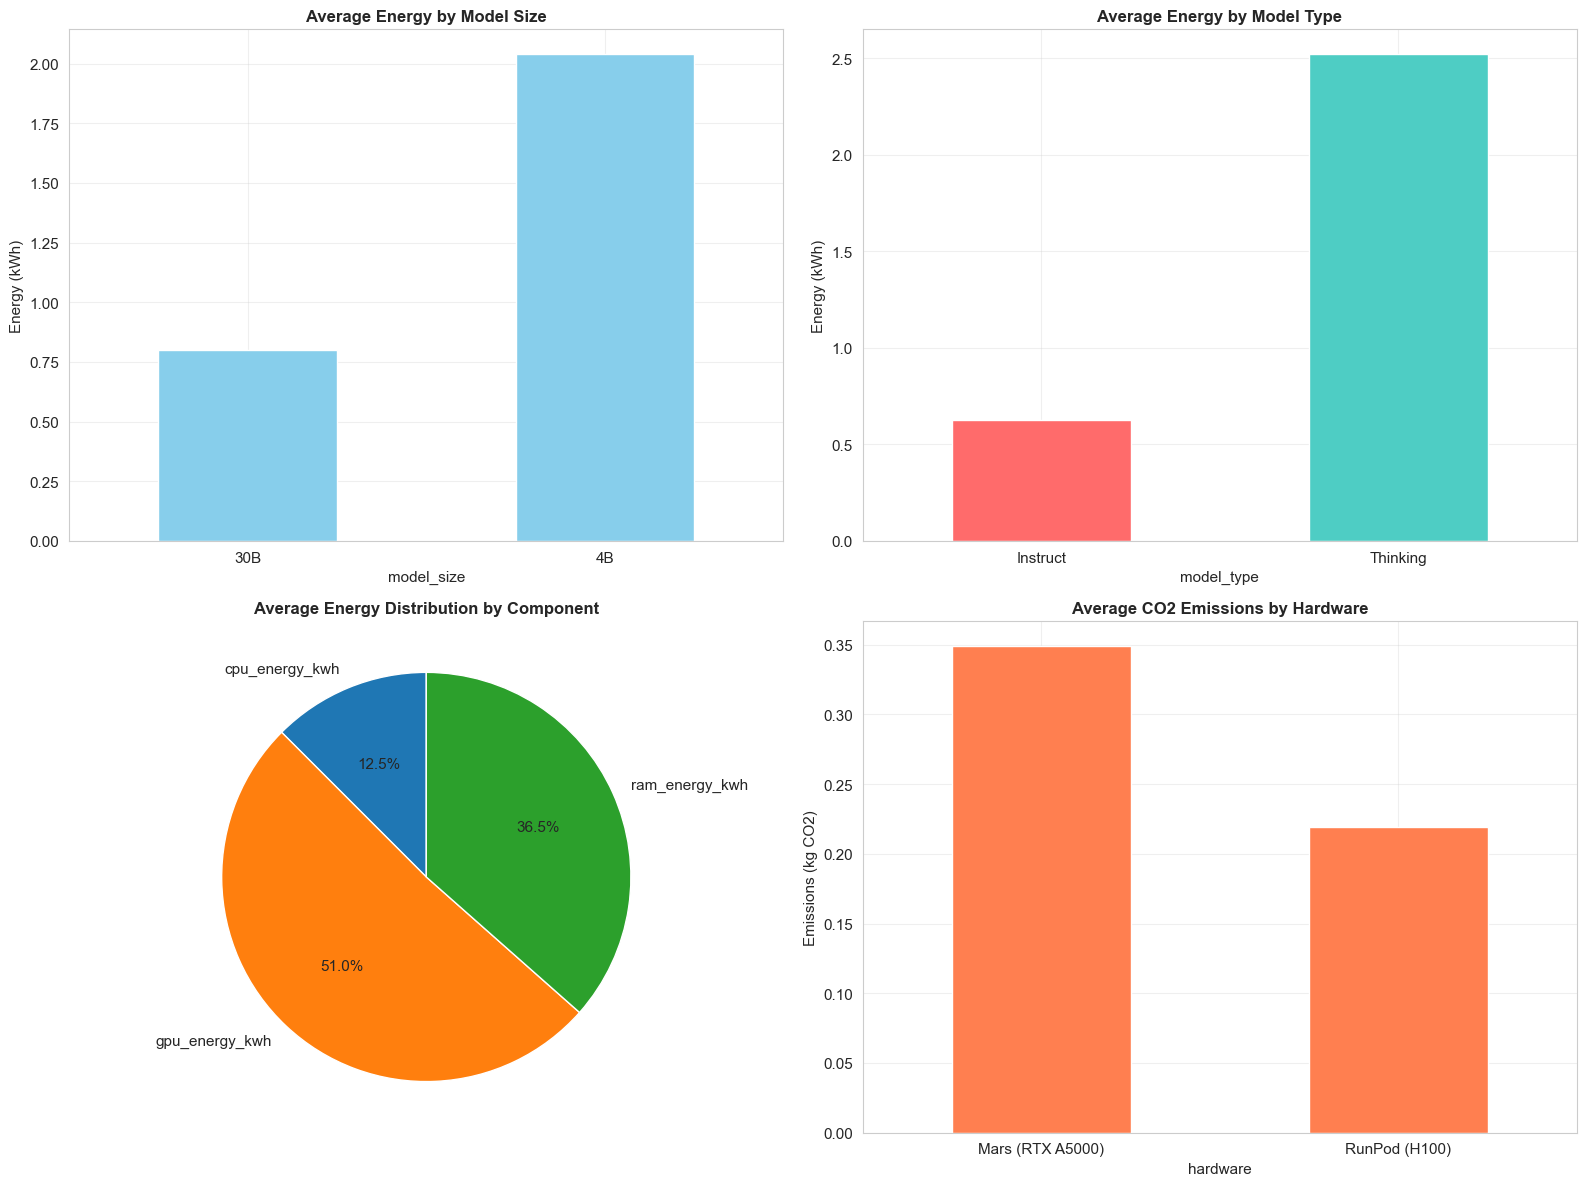


📊 Energy Component Breakdown (Average):
CPU Energy: 0.1969 kWh (12.5%)
GPU Energy: 0.8033 kWh (51.0%)
RAM Energy: 0.5755 kWh (36.5%)


In [11]:
# Energy comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Total energy by model size
energy_by_size = df_clean.groupby('model_size')['energy_consumed_kwh'].mean()
energy_by_size.plot(kind='bar', ax=axes[0, 0], rot=0, color='skyblue')
axes[0, 0].set_title('Average Energy by Model Size', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Energy (kWh)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Total energy by model type
energy_by_type = df_clean.groupby('model_type')['energy_consumed_kwh'].mean()
energy_by_type.plot(kind='bar', ax=axes[0, 1], rot=0, color=['#FF6B6B', '#4ECDC4'])
axes[0, 1].set_title('Average Energy by Model Type', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Energy (kWh)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Component breakdown (CPU, GPU, RAM)
energy_components = df_clean[['cpu_energy_kwh', 'gpu_energy_kwh', 'ram_energy_kwh']].mean()
energy_components.plot(kind='pie', ax=axes[1, 0], autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Average Energy Distribution by Component', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('')

# 4. Emissions by hardware
emissions_by_hw = df_clean.groupby('hardware')['emissions_kg_codecarbon'].mean()
emissions_by_hw.plot(kind='bar', ax=axes[1, 1], rot=0, color='coral')
axes[1, 1].set_title('Average CO2 Emissions by Hardware', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Emissions (kg CO2)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_energy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Energy Component Breakdown (Average):")
print(f"CPU Energy: {energy_components['cpu_energy_kwh']:.4f} kWh ({energy_components['cpu_energy_kwh']/energy_components.sum()*100:.1f}%)")
print(f"GPU Energy: {energy_components['gpu_energy_kwh']:.4f} kWh ({energy_components['gpu_energy_kwh']/energy_components.sum()*100:.1f}%)")
print(f"RAM Energy: {energy_components['ram_energy_kwh']:.4f} kWh ({energy_components['ram_energy_kwh']/energy_components.sum()*100:.1f}%)")

### 7.2 Performance vs Energy Tradeoff

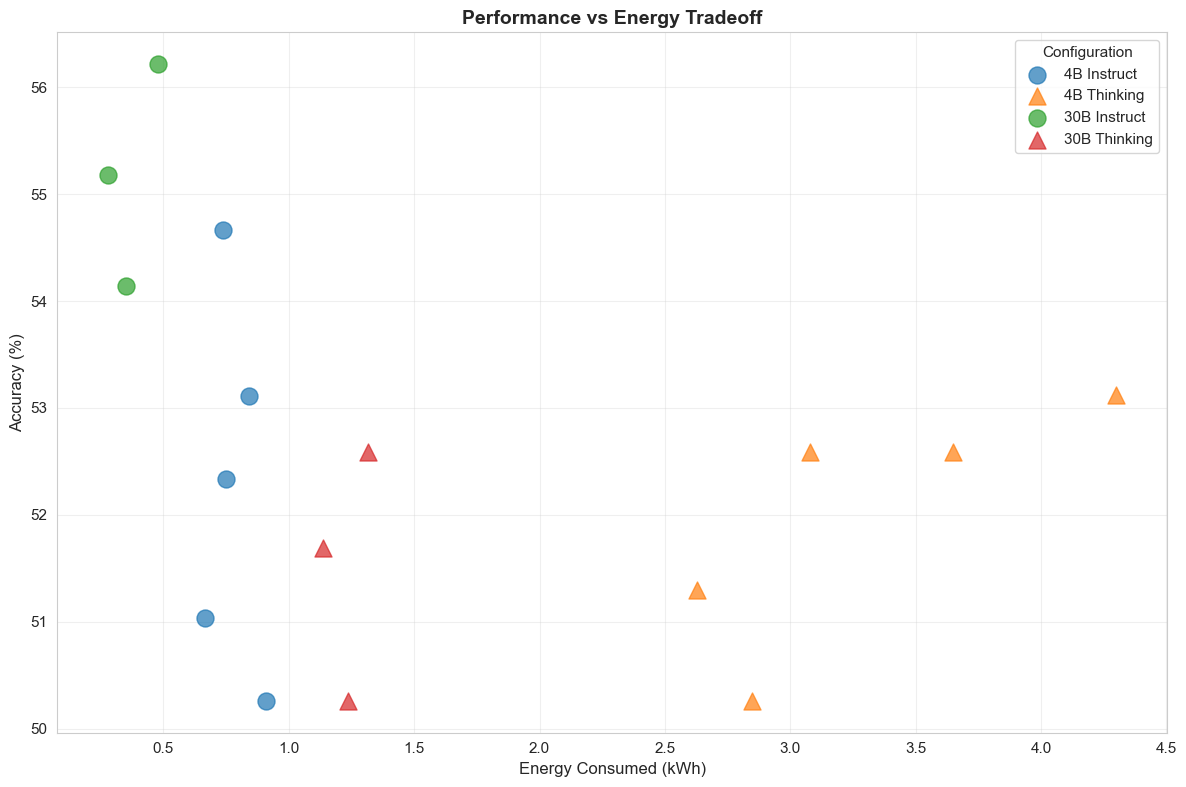


📊 Top 5 Most Efficient Configurations (Accuracy per kWh):
                                       experiment_id  Accuracy_pct  energy_consumed_kwh  efficiency
 30B_Instruct_Few-shot_Phase 2a (RunPod 30B Initial)     55.181347             0.278148  198.388542
30B_Instruct_Zero-shot_Phase 2a (RunPod 30B Initial)     54.145078             0.348762  155.249261
   30B_Instruct_Few-shot_Phase 2b (RunPod 30B Rerun)     56.217617             0.477449  117.745783
         4B_Instruct_Few-shot_Phase 1 (Mars Initial)     51.036269             0.666897   76.527943
          4B_Instruct_Few-shot_Phase 1b (Mars Rerun)     54.663212             0.737364   74.133314


In [12]:
# Scatter plot: Accuracy vs Energy
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Different colors/markers for model size and type
for model_size in df_clean['model_size'].unique():
    for model_type in df_clean['model_type'].unique():
        subset = df_clean[(df_clean['model_size'] == model_size) & (df_clean['model_type'] == model_type)]
        marker = 'o' if model_type == 'Instruct' else '^'
        ax.scatter(
            subset['energy_consumed_kwh'],
            subset['Accuracy_pct'],
            s=150,
            alpha=0.7,
            marker=marker,
            label=f"{model_size} {model_type}"
        )

ax.set_xlabel('Energy Consumed (kWh)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Performance vs Energy Tradeoff', fontsize=14, fontweight='bold')
ax.legend(title='Configuration', loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_performance_energy_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate efficiency metric (Accuracy per kWh)
df_clean['efficiency'] = df_clean['Accuracy_pct'] / df_clean['energy_consumed_kwh']
print("\n📊 Top 5 Most Efficient Configurations (Accuracy per kWh):")
print(df_clean.nlargest(5, 'efficiency')[['experiment_id', 'Accuracy_pct', 'energy_consumed_kwh', 'efficiency']].to_string(index=False))

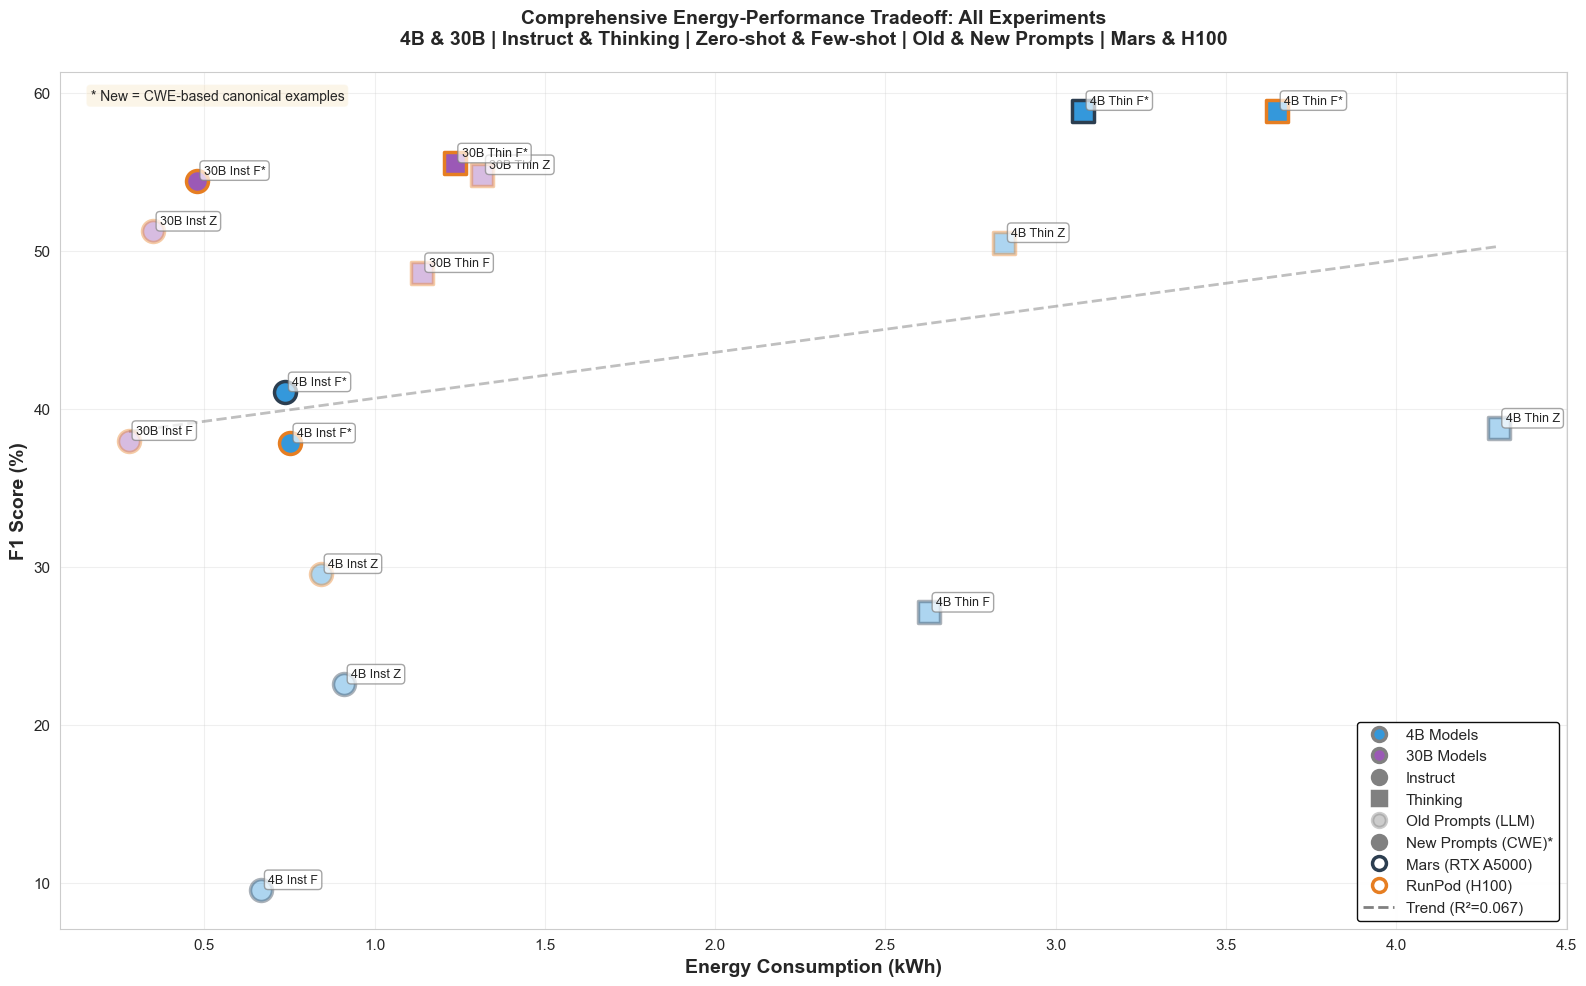


📊 Enhanced scatter plot saved!
   Trend line: R² = 0.067, p-value = 0.3328
   ⚠️  No statistically significant trend


In [13]:
### 7.3 Enhanced F1 Score vs Energy Tradeoff (with Labels)

# Create comprehensive labeled scatter plot similar to the reference image
fig, ax = plt.subplots(1, 1, figsize=(16, 10))

# Define colors and markers
size_colors = {'4B': '#3498DB', '30B': '#9B59B6'}  # Blue for 4B, Purple for 30B
type_markers = {'Instruct': 'o', 'Thinking': 's'}  # Circle for Instruct, Square for Thinking
hardware_edge_colors = {'Mars (RTX A5000)': '#2C3E50', 'RunPod (H100)': '#E67E22'}  # Dark gray for Mars, Orange for H100

# Plot each experiment with labels
for idx, row in df_clean.iterrows():
    model_size = row['model_size']
    model_type = row['model_type']
    prompt_version = row['prompt_version']
    prompting = row['prompting']
    hardware = row['hardware']

    # Always fill with model size color
    facecolor = size_colors[model_size]
    
    # Use transparency to distinguish prompt versions (opaque for CWE, semi-transparent for LLM)
    alpha = 1.0 if prompt_version == 'CWE-based' else 0.4
    
    # Edge color based on hardware
    edgecolor = hardware_edge_colors[hardware]
    linewidth = 2.5

    # Plot the point
    ax.scatter(
        row['energy_consumed_kwh'],
        row['F1_Score_pct'],
        s=250,
        marker=type_markers[model_type],
        facecolors=facecolor,
        edgecolors=edgecolor,
        linewidths=linewidth,
        alpha=alpha,
        zorder=3
    )

    # Create label: "30B Inst F*" format
    size_label = model_size
    type_label = 'Inst' if model_type == 'Instruct' else 'Thin'
    prompt_label = prompting[0].upper()  # Z for Zero-shot, F for Few-shot
    version_marker = '*' if prompt_version == 'CWE-based' else ''

    label = f"{size_label} {type_label} {prompt_label}{version_marker}"

    # Add label with offset
    ax.annotate(
        label,
        xy=(row['energy_consumed_kwh'], row['F1_Score_pct']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.7)
    )

# Add trend line
from scipy import stats as sp_stats
x = df_clean['energy_consumed_kwh'].values
y = df_clean['F1_Score_pct'].values
slope, intercept, r_value, p_value, std_err = sp_stats.linregress(x, y)
line_x = np.array([x.min(), x.max()])
line_y = slope * line_x + intercept
ax.plot(line_x, line_y, '--', color='gray', linewidth=2, alpha=0.5,
        label=f'Trend (R²={r_value**2:.3f})', zorder=1)

# Styling
ax.set_xlabel('Energy Consumption (kWh)', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score (%)', fontsize=14, fontweight='bold')
ax.set_title('Comprehensive Energy-Performance Tradeoff: All Experiments\n' +
             '4B & 30B | Instruct & Thinking | Zero-shot & Few-shot | Old & New Prompts | Mars & H100',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, zorder=0)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498DB', markeredgecolor='gray',
           markersize=10, markeredgewidth=2.5, label='4B Models', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9B59B6', markeredgecolor='gray',
           markersize=10, markeredgewidth=2.5, label='30B Models', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='gray',
           markersize=10, markeredgewidth=2.5, label='Instruct', linewidth=0),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='gray',
           markersize=10, markeredgewidth=2.5, label='Thinking', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='gray',
           markersize=10, markeredgewidth=2.5, alpha=0.4, label='Old Prompts (LLM)', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='gray',
           markersize=10, markeredgewidth=2.5, alpha=1.0, label='New Prompts (CWE)*', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor='#2C3E50',
           markersize=10, markeredgewidth=2.5, label='Mars (RTX A5000)', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor='#E67E22',
           markersize=10, markeredgewidth=2.5, label='RunPod (H100)', linewidth=0),
    Line2D([0], [0], color='gray', linewidth=2, linestyle='--',
           label=f'Trend (R²={r_value**2:.3f})')
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=11,
          framealpha=0.95, edgecolor='black', title_fontsize=12)

# Add note
ax.text(0.02, 0.98, '* New = CWE-based canonical examples',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_f1_energy_tradeoff_labeled.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Enhanced scatter plot saved!")
print(f"   Trend line: R² = {r_value**2:.3f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("   ✅ Statistically significant trend!")
else:
    print("   ⚠️  No statistically significant trend")

## 8. Summary Tables & Export

In [14]:
# Create comprehensive summary table
summary_table = df_clean[[
    'experiment_id', 'phase', 'hardware', 'model_size', 'model_type', 'prompting', 'prompt_version',
    'Accuracy_pct', 'Precision_pct', 'Recall_pct', 'F1_Score_pct',
    'energy_consumed_kwh', 'emissions_kg_codecarbon', 'duration_hours',
    'cpu_energy_kwh', 'gpu_energy_kwh', 'ram_energy_kwh'
]].copy()

# Round numeric columns
numeric_cols = summary_table.select_dtypes(include=[np.number]).columns
summary_table[numeric_cols] = summary_table[numeric_cols].round(3)

# Export to Excel
excel_file = OUTPUT_DIR / 'vuln_detection_comprehensive_analysis.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    summary_table.to_excel(writer, sheet_name='All Experiments', index=False)
    
    # Add aggregated views
    df_clean.groupby('model_size')[['Accuracy_pct', 'F1_Score_pct', 'energy_consumed_kwh']].mean().round(2).to_excel(
        writer, sheet_name='By Model Size'
    )
    
    df_clean.groupby('model_type')[['Accuracy_pct', 'F1_Score_pct', 'energy_consumed_kwh']].mean().round(2).to_excel(
        writer, sheet_name='By Model Type'
    )
    
    df_clean.groupby('prompting')[['Accuracy_pct', 'F1_Score_pct', 'energy_consumed_kwh']].mean().round(2).to_excel(
        writer, sheet_name='By Prompting'
    )
    
    df_clean.groupby('hardware')[['Accuracy_pct', 'F1_Score_pct', 'energy_consumed_kwh']].mean().round(2).to_excel(
        writer, sheet_name='By Hardware'
    )

print(f"\n✅ Analysis complete!")
print(f"📊 Excel file saved: {excel_file}")
print(f"🖼️  Visualizations saved to: {OUTPUT_DIR}/")

# Display final summary
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"\nTotal Experiments Analyzed: {len(df_clean)}")
print(f"\nBest Accuracy: {df_clean['Accuracy_pct'].max():.2f}% ({df_clean.loc[df_clean['Accuracy_pct'].idxmax(), 'experiment_id']})")
print(f"Most Energy Efficient: {df_clean.loc[df_clean['efficiency'].idxmax(), 'experiment_id']}")
print(f"\nAverage Accuracy: {df_clean['Accuracy_pct'].mean():.2f}%")
print(f"Average Energy: {df_clean['energy_consumed_kwh'].mean():.3f} kWh")
print(f"Average Emissions: {df_clean['emissions_kg_codecarbon'].mean():.3f} kg CO2")
print("\n" + "="*80)


✅ Analysis complete!
📊 Excel file saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis/vuln_detection_comprehensive_analysis.xlsx
🖼️  Visualizations saved to: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis/

FINAL SUMMARY

Total Experiments Analyzed: 16

Best Accuracy: 56.22% (30B_Instruct_Few-shot_Phase 2b (RunPod 30B Rerun))
Most Energy Efficient: 30B_Instruct_Few-shot_Phase 2a (RunPod 30B Initial)

Average Accuracy: 52.58%
Average Energy: 1.576 kWh
Average Emissions: 0.268 kg CO2



## 9. Key Findings

**To be filled after analysis:**

### RQ1: Model Size & Reasoning Impact
- Model size impact: [TBD]
- Reasoning capability impact: [TBD]

### RQ2: Prompting Strategy
- Zero-shot vs Few-shot: [TBD]
- Prompt engineering impact: [TBD]

### RQ3: Hardware Impact
- Performance comparison: [TBD]
- Energy efficiency: [TBD]

### Energy Analysis
- Component breakdown: [TBD]
- Optimal configurations: [TBD]